In [ ]:
import pandas as pd
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/combined_data.csv')

In [ ]:
df

,formatted_article,nepali_summary
0,"""आर्टिफिसियल इन्टेलिजेन्स (एआई) को क्षेत्रमा क...",नेपालको स्वामित्वमा रहेको आर्टिफिसियल इन्टेलिज...
1,"""काठमाण्डाै – नेपाल आयल निगमले आगामी माघ १ गते...","नेपाल आयल निगमले विभिन्न डिपोमा पेट्रोल, डिजेल..."
2,"""नेपाली पर्यटकका लागि सबैभन्दा आकर्षक बाह्य पर...","भारत, संयुक्त अरब इमिरेट्स (युएई) र थाइल्याण्ड..."
3,"""काठमाण्डाै – सुनचाँदीको मूल्य माथी उकालो लागे...",नेपाल सुनचाँदी व्यवसायी महासंघका अनुसार आज छाप...
4,"""नेपाल विद्युत् प्राधिकरणले डेडिकेटेड फिडर र ट...",नेपाल विद्युत् प्राधिकरणले बारा–पर्सा औद्योगिक...
...,...,...
5043,काठमाडौँ– आगामी मंसिर १० गते एकै चरणमा हुने प्...,निर्वाचन आयोगले प्रतिनिधिसभा र प्रदेशसभासदस्यक...
5044,नेपाली काँग्रेसका नेता डा शेखर कोइरालाले प्रदी...,नेपाली काँग्रेसका नेता डा शेखर कोइरालाले प्रदी...
5045,नेकपा (एमाले)का उपाध्यक्ष सुरेन्द्र पाण्डेले प...,नेकपा (एमाले)का उपाध्यक्ष सुरेन्द्र पाण्डेले प...
5046,नेकपा (एकीकृत समाजवादी)का अध्यक्ष एवं पूर्वप्र...,नेपाल कम्युनिष्ट पार्टी (नेकपा)का अध्यक्ष एवं ...


In [ ]:
# Get basic information about the dataset
print("Shape of the dataset:", df.shape)  # Rows and columns
print("\nData types of each column:\n", df.dtypes)  # Data types
print("\nDescriptive statistics:\n", df.describe())  # Summary statistics

Shape of the dataset: (5048, 2)

Data types of each column:
 formatted_article    object
nepali_summary       object
dtype: object

Descriptive statistics:
                                         formatted_article  \
count                                                5048   
unique                                               5015   
top     प्रधानमन्त्री पुष्पकमल दाहाल 'प्रचण्ड'को परराष...   
freq                                                    2   

                                           nepali_summary  
count                                                5048  
unique                                               5022  
top     साफ महिला च्याम्पियनसिपको फाइनल खेलमा बंगलादेश...  
freq                                                    2  


In [ ]:
!pip install transformers sentencepiece datasets torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch
from transformers import T5ForConditionalGeneration, T5Tokenizer


In [ ]:
from huggingface_hub import notebook_login

notebook_login()


In [ ]:
from transformers import MT5ForConditionalGeneration, T5Tokenizer

MODEL_NAME = "google/mt5-small"  # Ensure it's an mT5 model

# Load tokenizer and model
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)
model = MT5ForConditionalGeneration.from_pretrained(MODEL_NAME)

In [ ]:
# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

MT5ForConditionalGeneration(
  (shared): Embedding(250112, 512)
  (encoder): MT5Stack(
    (embed_tokens): Embedding(250112, 512)
    (block): ModuleList(
      (0): MT5Block(
        (layer): ModuleList(
          (0): MT5LayerSelfAttention(
            (SelfAttention): MT5Attention(
              (q): Linear(in_features=512, out_features=384, bias=False)
              (k): Linear(in_features=512, out_features=384, bias=False)
              (v): Linear(in_features=512, out_features=384, bias=False)
              (o): Linear(in_features=384, out_features=512, bias=False)
              (relative_attention_bias): Embedding(32, 6)
            )
            (layer_norm): MT5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): MT5LayerFF(
            (DenseReluDense): MT5DenseGatedActDense(
              (wi_0): Linear(in_features=512, out_features=1024, bias=False)
              (wi_1): Linear(in_features=512, out_features=1024, bias=False)
          

In [ ]:
from datasets import Dataset

# Convert pandas dataframe to Hugging Face dataset
dataset = Dataset.from_pandas(df)

# Split into train and validation sets (80% train, 20% validation)
dataset = dataset.train_test_split(test_size=0.2)

train_dataset = dataset["train"]
eval_dataset = dataset["test"]

# Check the dataset structure
print(train_dataset)


Dataset({
    features: ['formatted_article', 'nepali_summary'],
    num_rows: 4038
})


In [ ]:
def preprocess_function(examples):
    inputs = ["summarize: " + text for text in examples["formatted_article"]]  # Use formatted_article
    model_inputs = tokenizer(inputs, max_length=512, truncation=True, padding="max_length")

    # Tokenize summary as labels
    labels = tokenizer(examples["nepali_summary"], max_length=150, truncation=True, padding="max_length")
    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

# Apply tokenization
tokenized_datasets = dataset.map(preprocess_function, batched=True)

# Extract train and evaluation datasets
train_dataset = tokenized_datasets["train"]
eval_dataset = tokenized_datasets["test"]




Map:   0%|          | 0/4038 [00:00<?, ? examples/s]

Map:   0%|          | 0/1010 [00:00<?, ? examples/s]

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",  # Output directory for model checkpoints
    run_name="Nepali_T5_Summarization_Exp1",  # Unique name for tracking
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    save_total_limit=2
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,  # Your preprocessed training dataset
    eval_dataset=eval_dataset,    # Your validation dataset
)


In [ ]:
# Start training
trainer.train()

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: suprishmamaharjan44284046 (suprishmamaharjan44284046-khec) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Epoch,Training Loss,Validation Loss
1,2.424200,1.672139
2,2.240600,1.506410
3,1.880000,1.472147


TrainOutput(global_step=3030, training_loss=3.0923245968204913, metrics={'train_runtime': 1703.4185, 'train_samples_per_second': 7.112, 'train_steps_per_second': 1.779, 'total_flos': 6405273755320320.0, 'train_loss': 3.0923245968204913, 'epoch': 3.0})

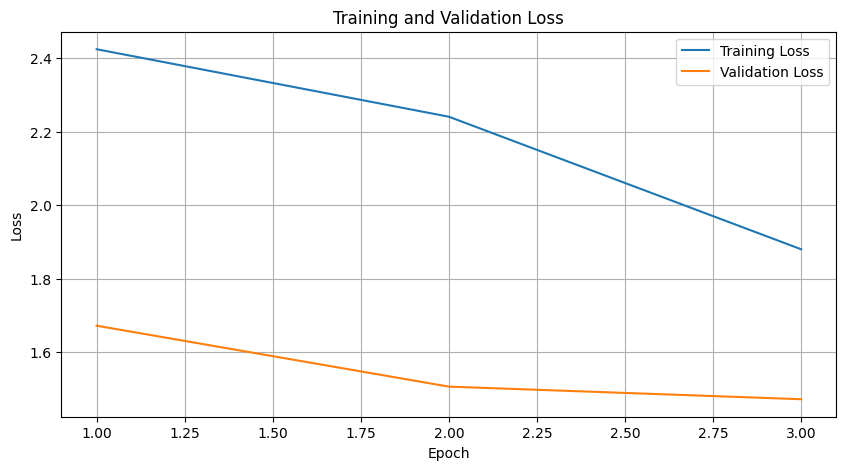

In [1]:
import matplotlib.pyplot as plt

# Epoch and Loss data
epoch = [1, 2, 3]
train_loss = [2.424200, 2.240600	, 1.880000]
val_loss = [1.672139, 1.506410, 1.472147]

# Create the plot
plt.figure(figsize=(10, 5))
plt.plot(epoch, train_loss, label='Training Loss')
plt.plot(epoch, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Save dataset
df.to_csv('/content/drive/MyDrive/combined_data.csv', index=False)

# Save trained model
model.save_pretrained('/content/drive/MyDrive/mt5_nepali_summarizer')
tokenizer.save_pretrained('/content/drive/MyDrive/mt5_nepali_summarizer')


('/content/drive/MyDrive/mt5_nepali_summarizer/tokenizer_config.json',
 '/content/drive/MyDrive/mt5_nepali_summarizer/special_tokens_map.json',
 '/content/drive/MyDrive/mt5_nepali_summarizer/spiece.model',
 '/content/drive/MyDrive/mt5_nepali_summarizer/added_tokens.json')